In [1]:
# Imports + chemins + device
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import ioumatch

PROJECT_ROOT = Path(".").resolve()
PREP_ROOT = PROJECT_ROOT / "data" / "prepared" / "pannuke"
CKPT_DIR  = PROJECT_ROOT / "models" / "checkpoints"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("PREP_ROOT:", PREP_ROOT)
print("CKPT_DIR :", CKPT_DIR)


device: cuda
PREP_ROOT: C:\Users\yehadji\Desktop\projects\ME\cell_segmentation\data\prepared\pannuke
CKPT_DIR : C:\Users\yehadji\Desktop\projects\ME\cell_segmentation\models\checkpoints


In [2]:
# Charger 1 image val brute (sans transform)
from src.pannuke_dataset import PannukePreparedDataset

val_raw = PannukePreparedDataset(
    root=PREP_ROOT,
    split="test",
    transform=None,
    return_image_name=True,
)

img_t, gt_inst_t, types_t, name = val_raw[0]
img = img_t.permute(1,2,0).numpy()
gt_inst = gt_inst_t.numpy().astype(np.int32)

print("name:", name, "img:", img_t.shape, "GT instances:", int(gt_inst.max()))


name: img_005086.npy img: torch.Size([3, 256, 256]) GT instances: 13


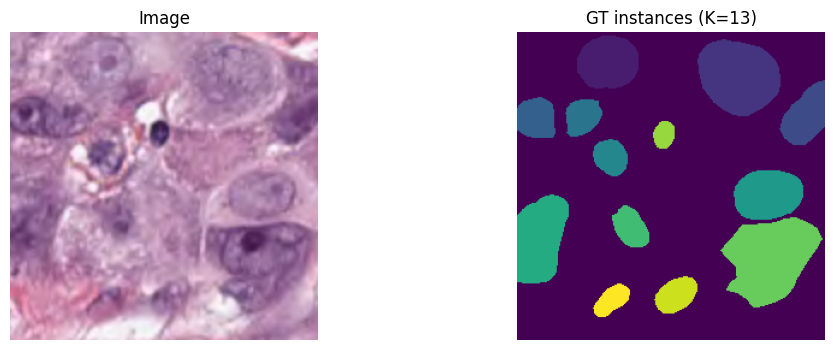

In [3]:
# Visualiser l'image + GT
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.title("Image"); plt.imshow(img); plt.axis("off")
plt.subplot(1,2,2); plt.title(f"GT instances (K={gt_inst.max()})"); plt.imshow(gt_inst); plt.axis("off")
plt.show()


In [4]:
# Métriques (pixel + instance)

def dice_bin(pred_bin: np.ndarray, gt_bin: np.ndarray, eps=1e-7) -> float:
    pred = pred_bin.astype(bool)
    gt = gt_bin.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    denom = pred.sum() + gt.sum()
    return float((2.0 * inter + eps) / (denom + eps))

def iou_bin(pred_bin: np.ndarray, gt_bin: np.ndarray, eps=1e-7) -> float:
    pred = pred_bin.astype(bool)
    gt = gt_bin.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return float((inter + eps) / (union + eps))

def f1_instance(pred_inst: np.ndarray, gt_inst: np.ndarray, iou_thr=0.5):
    res = ioumatch.evaluate_image(
        pred_inst.astype(np.int32),
        gt_inst.astype(np.int32),
        threshold=iou_thr,
        method="greedy",
        inclusive=False,
        normalize=False,
    )
    tp = int(res["tp"]); fp = int(res["fp"]); fn = int(res["fn"])
    f1 = (2*tp) / max((2*tp + fp + fn), 1e-9)
    return float(f1), tp, fp, fn


In [5]:
# Post-processing U-Net (prob → instances)
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.morphology import remove_small_objects, h_maxima

def unet_prob_to_instances(prob, thr=0.5, min_size=20, h=1.5):
    bin_mask = prob > thr
    bin_mask = remove_small_objects(bin_mask, min_size=min_size)
    if bin_mask.sum() == 0:
        return np.zeros_like(prob, dtype=np.int32)

    dist = ndi.distance_transform_edt(bin_mask)
    seeds = h_maxima(dist, h=h)
    seeds &= bin_mask

    markers, _ = ndi.label(seeds)
    if markers.max() == 0:
        markers, _ = ndi.label(bin_mask)

    labels = watershed(-dist, markers, mask=bin_mask)
    return labels.astype(np.int32)


In [6]:
# Charger le checkpoint U-Net BEST + prédire 1 image
from models.unet import UNet

UNET_BEST = CKPT_DIR / "unet_pannuke_lit_best.ckpt"

print("UNET_BEST:", UNET_BEST, "exists:", UNET_BEST.exists())

unet = UNet(in_channels=3, out_channels=1, base_ch=64).to(device).eval()

ckpt = torch.load(UNET_BEST, map_location="cpu")
state = ckpt["state_dict"] if "state_dict" in ckpt else ckpt

# lightning keys "model.xxx"
new_state = {}
for k,v in state.items():
    if k.startswith("model."):
        new_state[k[len("model."):]] = v
    else:
        new_state[k] = v

missing, unexpected = unet.load_state_dict(new_state, strict=False)
print("missing:", missing)
print("unexpected:", unexpected)

with torch.no_grad():
    x = img_t.unsqueeze(0).to(device)
    logits = unet(x)[0,0].detach().cpu().numpy()
    prob_unet = 1.0 / (1.0 + np.exp(-logits))

pred_unet_inst = unet_prob_to_instances(prob_unet, thr=0.5, min_size=20, h=1.5)
print("pred instances:", int(pred_unet_inst.max()))


UNET_BEST: C:\Users\yehadji\Desktop\projects\ME\cell_segmentation\models\checkpoints\unet_pannuke_lit_best.ckpt exists: True
missing: []
unexpected: []
pred instances: 22


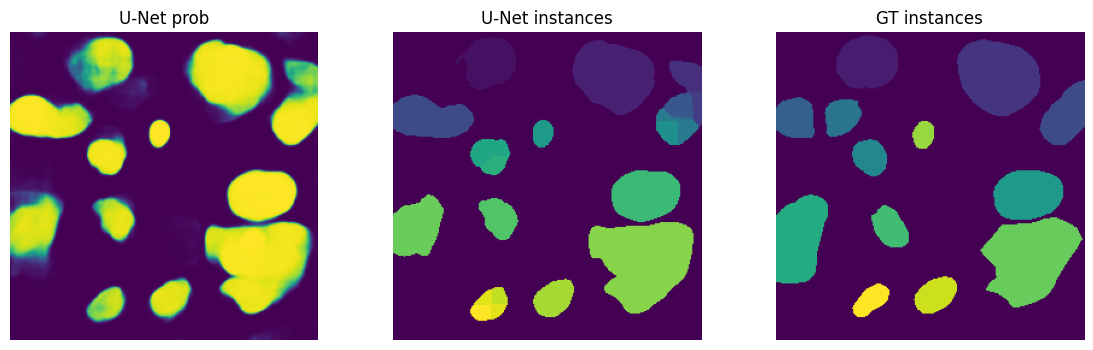

In [7]:
# Visu U-Net (prob + instances + GT)
plt.figure(figsize=(14,4))
plt.subplot(1,3,1); plt.title("U-Net prob"); plt.imshow(prob_unet); plt.axis("off")
plt.subplot(1,3,2); plt.title("U-Net instances"); plt.imshow(pred_unet_inst); plt.axis("off")
plt.subplot(1,3,3); plt.title("GT instances"); plt.imshow(gt_inst); plt.axis("off")
plt.show()


In [8]:
# Métriques U-Net sur cette image
gt_bin = (gt_inst > 0).astype(np.uint8)
pred_bin = (prob_unet > 0.5).astype(np.uint8)

dice_u = dice_bin(pred_bin, gt_bin)
iou_u  = iou_bin(pred_bin, gt_bin)
f1_u, tp_u, fp_u, fn_u = f1_instance(pred_unet_inst, gt_inst, iou_thr=0.5)

print(f"[U-Net] Dice={dice_u:.4f} IoU={iou_u:.4f} F1inst@0.5={f1_u:.4f} (TP/FP/FN={tp_u}/{fp_u}/{fn_u})")


[U-Net] Dice=0.8705 IoU=0.7707 F1inst@0.5=0.4571 (TP/FP/FN=8/14/5)


In [9]:
# Éval rapide sur 50 images val (moyenne)
def eval_unet_on_val(val_ds, n=50, seed=0, thr=0.5, min_size=20, h=1.5):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(val_ds), size=min(n, len(val_ds)), replace=False)

    rows = []
    for idx in idxs:
        img_t, gt_t, types_t, name = val_ds[idx]
        gt = gt_t.numpy().astype(np.int32)
        gt_bin = (gt > 0).astype(np.uint8)

        with torch.no_grad():
            prob = torch.sigmoid(unet(img_t.unsqueeze(0).to(device)))[0,0].detach().cpu().numpy()

        pred_inst = unet_prob_to_instances(prob, thr=thr, min_size=min_size, h=h)
        pred_bin = (prob > thr).astype(np.uint8)

        rows.append({
            "image": name,
            "dice": dice_bin(pred_bin, gt_bin),
            "iou":  iou_bin(pred_bin, gt_bin),
            "f1":   f1_instance(pred_inst, gt, iou_thr=0.5)[0],
            "gt_k": int(gt.max()),
            "pred_k": int(pred_inst.max()),
        })

    return pd.DataFrame(rows)

df_u = eval_unet_on_val(val_raw, n=50, seed=0, thr=0.5, min_size=20, h=1.5)
print(df_u[["dice","iou","f1"]].mean())
df_u.head()


dice    0.831419
iou     0.725025
f1      0.626138
dtype: float64


,image,dice,iou,f1,gt_k,pred_k
0,img_005282.npy,0.866494,0.764437,0.641026,32,46
1,img_005160.npy,0.855342,0.747247,0.571429,13,22
2,img_007318.npy,0.820154,0.695136,0.611111,27,45
3,img_007303.npy,0.857271,0.750196,0.536585,15,26
4,img_006998.npy,0.807321,0.676897,0.492308,33,32


In [ ]:
morph_csv = PREP_ROOT / "pannuke_morphology_with_classes.csv"
print("morph_csv exists:", morph_csv.exists(), morph_csv)

if morph_csv.exists():
    morph = pd.read_csv(morph_csv)
    morph_val = morph[morph["split"]=="test"].copy()

    img_area = morph_val.groupby("image")["area"].mean().rename("mean_area").reset_index()
    img_morph = morph_val.groupby("image")["morph_class"].agg(lambda x: x.value_counts().index[0]).rename("dom_morph").reset_index()

    df_u2 = df_u.merge(img_area, on="image", how="left").merge(img_morph, on="image", how="left")
    df_u2["size_bin"] = pd.qcut(df_u2["mean_area"].fillna(df_u2["mean_area"].median()), q=4, labels=["S","M","L","XL"])

    print("U-Net by dom_morph:\n", df_u2.groupby("dom_morph")[["dice","iou","f1"]].mean())
    print("U-Net by size_bin:\n", df_u2.groupby("size_bin")[["dice","iou","f1"]].mean())
else:
    print("Morph CSV not found, skip.")
